In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

E0000 00:00:1784675708.932438   40153 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784675708.937625   40153 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784675708.950852   40153 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784675708.950882   40153 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784675708.950885   40153 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784675708.950888   40153 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1784675711.751639   40153 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2217 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784675711.790803   40153 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2217 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784675711.832582   40153 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2217 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784675711.833977   40153 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2217 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784675711.835782   40153 gpu_device.cc:2019] Cr

# Load data

In [2]:
df = pd.read_csv("OASIS Data/patients_full_data.csv")
print("Data dimensions: {}".format(df.shape))
df.head(3)

Data dimensions: (737, 277)


,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,cdr,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


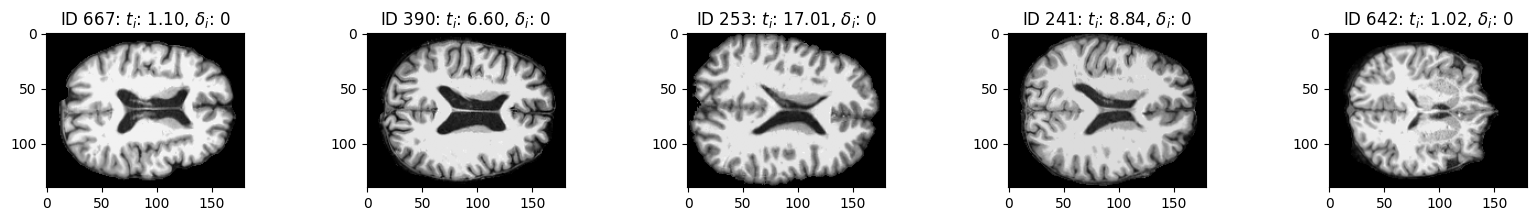

In [3]:
x = np.load("OASIS Data/patients_images.npy")
x = np.expand_dims(x, axis=-1)

np.random.seed(12)

random_idx = np.random.choice(np.arange(x.shape[0]), size = 5)

fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (20,2))

for i, a in enumerate(ax):
    idx = random_idx[i]
    a.imshow(x[idx,:,:,0], cmap = "gray")
    a.set_title(r"ID {}: $t_i$: {:.2f}, $\delta_i$: {}".format(idx, df.loc[idx, "time_days"] / 365, df.loc[idx, "delta"]))

In [4]:
from sklearn.model_selection import train_test_split

indices = np.arange(df.shape[0])
idx_train, idx_test = train_test_split(indices, train_size = 0.7, random_state = 42)

print("Train dimension: {}".format(idx_train.shape))
print("Test dimension: {}".format(idx_test.shape))

y_train = df.loc[idx_train, "time_days"] / 365
y_test = df.loc[idx_test, "time_days"] / 365
delta_train = df.loc[idx_train, "delta"]
delta_test = df.loc[idx_test, "delta"]

x_train = x[idx_train]
x_test = x[idx_test]

Train dimension: (515,)
Test dimension: (222,)


# Grad-CAM structure

In [53]:
import cv2

def get_last_conv_layer_index(model):
    conv_indices = []
    for i, layer in enumerate(model.layers):
        if(hasattr(layer, "convolution_op")):
            conv_indices.append(i)
    return conv_indices[-1]

def generate_gradcam(model, img):
    i_last_conv = get_last_conv_layer_index(model)
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    x = model.layers[0](img_tensor)
    with tf.GradientTape() as tape:
        for i in range(1, len(model.layers)):
            # If we are at the last convolution layer, get its output and save it in a separate variable
            if(i == i_last_conv):
                last_conv_out = x = model.layers[i](x)
                tape.watch(last_conv_out)
            # The next layer output is based on the last convolutional layer output
            elif(i == (i_last_conv + 1)):
                x = model.layers[i](last_conv_out)
            # All the other layers are simply applications of each layer
            else:
                x = model.layers[i](x)
        # Get the last output of the last layer, associated to the cure probability
        target_score = x[0,-1]

    grads = tape.gradient(target_score, last_conv_out)

    # Global Average Pooling of the gradients to get the weight of each feature map
    pooled_grads = tf.reduce_mean(grads, axis = (0, 1, 2))

    # Multiply the feature maps by their gradient weights
    last_conv_out = last_conv_out[0] # Drop the batch dimension
    heatmap = last_conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU (we only care about pixels that had a *positive* influence on the prediction)
    heatmap = tf.nn.relu(heatmap)

    # Normalize the heatmap to be between 0 and 1
    heatmap_max = tf.math.reduce_max(heatmap)
    if heatmap_max != 0:
        heatmap = heatmap / heatmap_max

    return heatmap.numpy()

def gradcam_img(model, img):
    heatmap = generate_gradcam(model, img)
    original_image = img[0, :, :, 0]
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    return heatmap_resized

def plot_gradcam(model, img):
    """
    Overlays the Grad-CAM heatmap onto the original MRI slice.
    """
    # Get the Grad-CAM heatmap
    heatmap = generate_gradcam(model, img)
    
    # Extract the original 2D image (dropping batch and channel dims)
    original_image = img[0, :, :, 0]
    
    # Resize heatmap to match the original image size -> OpenCV format (width, height)
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    
    # Convert heatmap to RGB format for visualization
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Convert original image to RGB
    original_img_norm = np.uint8(255 * (original_image / np.max(original_image)))
    original_colored = cv2.cvtColor(original_img_norm, cv2.COLOR_GRAY2RGB)
    
    # Blend them together (0.6 opacity for MRI, 0.4 for heatmap)
    superimposed_img = cv2.addWeighted(original_colored, 0.6, heatmap_colored, 0.4, 0)
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title("Original MRI Slice")
    ax[0].axis('off')
    
    ax[1].imshow(heatmap_resized, cmap='jet')
    ax[1].set_title("Raw Grad-CAM")
    ax[1].axis('off')
    
    ax[2].imshow(superimposed_img)
    ax[2].set_title("Overlay")
    ax[2].axis('off')
    
    plt.show()

# Neural network architecture

In [6]:
def neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    
    model.convolution1 = keras.layers.Conv2D(filters = 4, kernel_size = [7,7], padding = "same", activation = tf.nn.leaky_relu,
                                            kernel_initializer = initializer, dtype = tf.float32)
    model.pooling1 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
    model.convolution2 = keras.layers.Conv2D(filters = 8, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                            kernel_initializer = initializer, dtype = tf.float32)
    model.pooling2 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
    model.convolution3 = keras.layers.Conv2D(filters = 16, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                            kernel_initializer = initializer, dtype = tf.float32)
    model.pooling3 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)

    model.convolution4 = keras.layers.Conv2D(filters = 32, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
    model.pooling4 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)

    model.convolution5 = keras.layers.Conv2D(filters = 64, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
    model.pooling5 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
    model.flatten = keras.layers.Reshape(target_shape=(-1,))
    model.dense1 = keras.layers.Dense(units = 128, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
    model.dense2 = keras.layers.Dense(units = 4, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
    model.dense3 = keras.layers.Dense(units = 10, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = False)
    
def neural_network_call(model, x_input, training = False):
    x = model.convolution1(x_input)
    x = model.pooling1(x)
    x = model.convolution2(x)
    x = model.pooling2(x)
    x = model.convolution3(x)
    x = model.pooling3(x)
    x = model.convolution4(x)
    x = model.pooling4(x)
    x = model.convolution5(x)
    x = model.pooling5(x)
    x = model.flatten(x)
    x = model.dense1(x)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

def neural_network_call_nolast(model, x_input):
    x = model.convolution1(x_input)
    x = model.pooling1(x)
    x = model.convolution2(x)
    x = model.pooling2(x)
    x = model.convolution3(x)
    x = model.pooling3(x)
    x = model.convolution4(x)
    x = model.pooling4(x)
    x = model.convolution5(x)
    x = model.pooling5(x)
    x = model.flatten(x)
    x = model.dense1(x)
    x = model.dense2(x)
    return x

First, we will consider the standard promotion time cure model proposed by Xie & Yu (2021). For that, we consider the Poisson distribution for the number of latent causes. Below is the code to consider that model and train it.

In [7]:
poisson_spec = mpscr.MPSPoisson()
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 8)
poisson_model = mpscr.build_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, pwexp_spec,
                                        neural_network = neural_network, neural_network_call = neural_network_call,
                                        neural_network_call_nolast = neural_network_call_nolast,
                                        seed = 10)

keras.Model.summary(poisson_model)

Model: "model_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 140, 180, 4)    │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 90, 8)      │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 35, 45, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 22, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 11, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            40 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,884 (749.55 KB)

 Trainable params: 191,884 (749.55 KB)

 Non-trainable params: 0 (0.00 B)

### Piecewise-exponential base

In [8]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

poisson_spec = mpscr.MPSPoisson()
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 8)

with tf.device("/GPU:0"):
    poisson_model = mpscr.build_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, pwexp_spec,
                                            neural_network = neural_network, neural_network_call = neural_network_call,
                                            neural_network_call_nolast = neural_network_call_nolast,
                                            seed = 10)
    poisson_model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = False,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
    
    poisson_results = poisson_model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...


I0000 00:00:1784675724.580889   40269 cuda_dnn.cc:529] Loaded cuDNN version 92400


Optimizing... Epoch: [ 404 / 5000 ]  | Avg. Train NLL:  0.417308 | Avg. Validation NLL:  0.563781321 | Best Avg. Validation NLL:  0.55012387 | Speed:  0.172097564  epoch/s    | Elapsed Time:  69.5274124  s       
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 757 / 5000 ]  | Avg. Train NLL:  0.272342771 | Best Avg. Train NLL:  0.272342771 | Avg. Validation NLL:  0.453618407 | Speed:  0.0701267645  epoch/s    | Elapsed Time:  53.0859604  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 134.722 seconds.


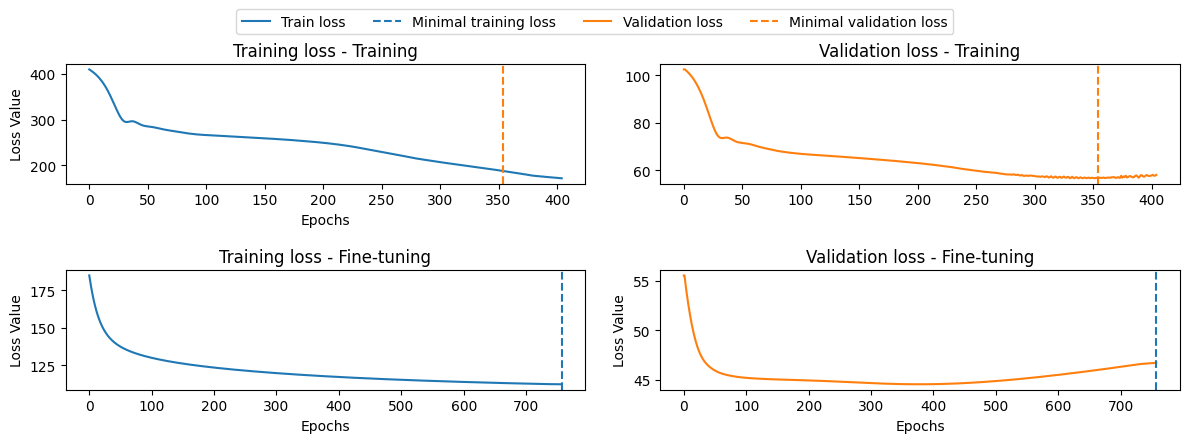

In [9]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,4))

utils.plot_model_convergence( poisson_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

It seems that the neural network was not able to properly learn the convolutional features of the data.

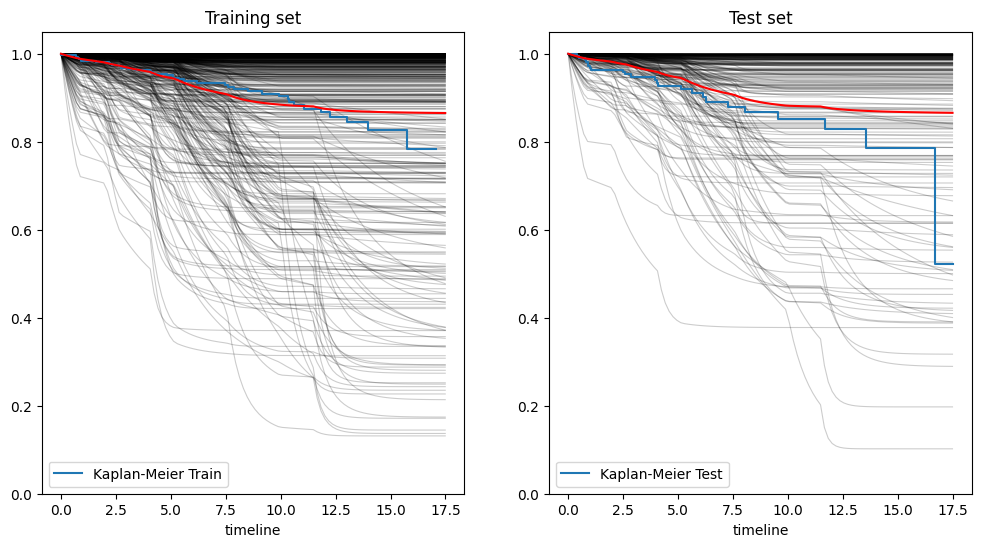

In [55]:
ts_grid = poisson_results["ts_grid"]
p_train = poisson_results["p_train"].numpy()
p_test = poisson_results["p_test"].numpy()
S_ts_train = poisson_results["S_ts_train"].numpy()
S_ts_test = poisson_results["S_ts_test"].numpy()

# Should we consider these curves for the Kaplan-Meier assessment? Both plots look fine anyway!
# S_ts_train[delta_train == 1,:] = (S_ts_train[delta_train == 1,:] - p_train[delta_train == 1]) / (1 - p_train[delta_train == 1])
# S_ts_test[delta_test == 1,:] = (S_ts_test[delta_test == 1,:] - p_test[delta_test == 1]) / (1 - p_test[delta_test == 1])

utils.average_kaplan_meier_train_test(ts_grid[:,None],
                                      S_ts_train.T, S_ts_test.T,
                                      y_train, delta_train, y_test, delta_test, show_individual = True)

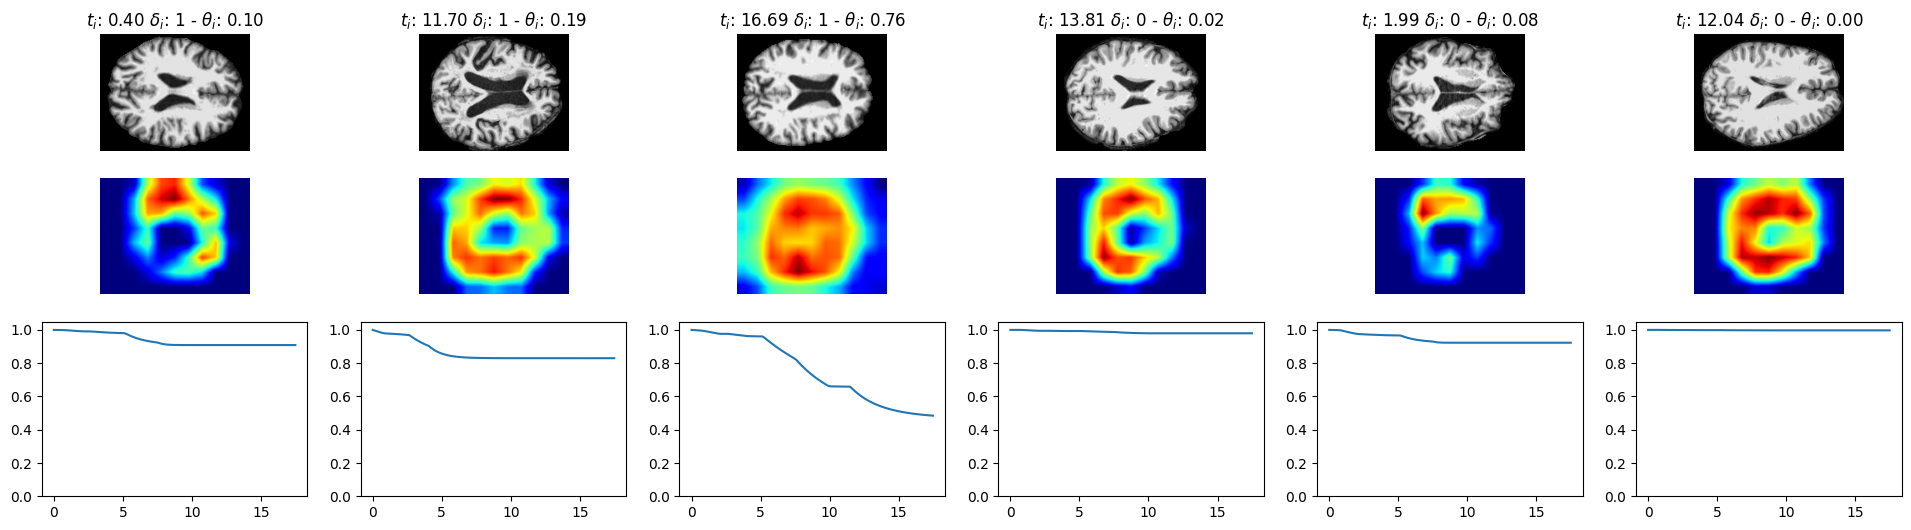

In [54]:
# np.random.seed(3)
np.random.seed(15)

# Select five patients from the test set who happened to be diagnosed with AD
susceptible_idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = delta_test / np.sum(delta_test))
# Sample 5 patients from the test set whose lifetimes are censored
idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = (1-delta_test) / np.sum(1-delta_test))

idx[:3] = susceptible_idx[:3]

fig, ax = plt.subplots(nrows = 3, ncols = 6, figsize = (24,6),
                       gridspec_kw = {
                           'height_ratios': [1,1,1.5],
                           'width_ratios': [1,1,1,1,1,1]
                       })
    
t = np.linspace(0.01, np.max(y_train))

for i in range(6):
    ax[0,i].imshow( x_test[idx[i]], cmap = "gray" )
    ax[0,i].set_title(r"$t_i$: {:.2f} $\delta_i$: {} - $\theta_i$: {:.2f}".format(y_test.iloc[idx[i]], delta_test.iloc[idx[i]], poisson_results["theta_test"].numpy()[idx[i],0]))
    ax[0,i].set_axis_off()

    gradcam = gradcam_img(poisson_model, x_test[idx[i]:(idx[i]+1)] )
    ax[1,i].imshow( gradcam, cmap = "jet" )
    ax[1,i].set_axis_off()

    ax[2,i].plot( poisson_results["ts_grid"].flatten(), poisson_results["S_ts_test"].numpy()[idx[i], :] )
    ax[2,i].set_ylim(0, 1.05)

Text(0.5, 1.0, 'Train set uncensored')

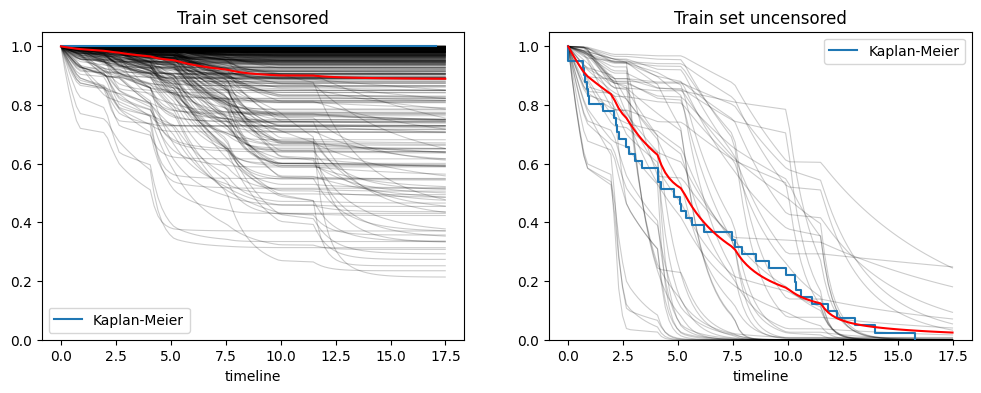

In [28]:
ts_grid = poisson_results["ts_grid"]

p_train = poisson_results["p_train"].numpy()
S_ts_train = poisson_results["S_ts_train"].numpy()
S_ts_train_censored = S_ts_train[delta_train == 0, :]

S_ts_train_uncensored = (S_ts_train[delta_train == 1, :] - p_train[delta_train == 1]) / (1-p_train[delta_train == 1])

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier(ts_grid[:,None],
                           S_ts_train_censored.T,
                           y_train[delta_train == 0], delta_train[delta_train == 0], show_individual = True, ax = ax[0])
ax[0].set_title("Train set censored")

utils.average_kaplan_meier(ts_grid[:,None],
                           S_ts_train_uncensored.T,
                           y_train[delta_train == 1], delta_train[delta_train == 1], show_individual = True, ax = ax[1])
ax[1].set_title("Train set uncensored")

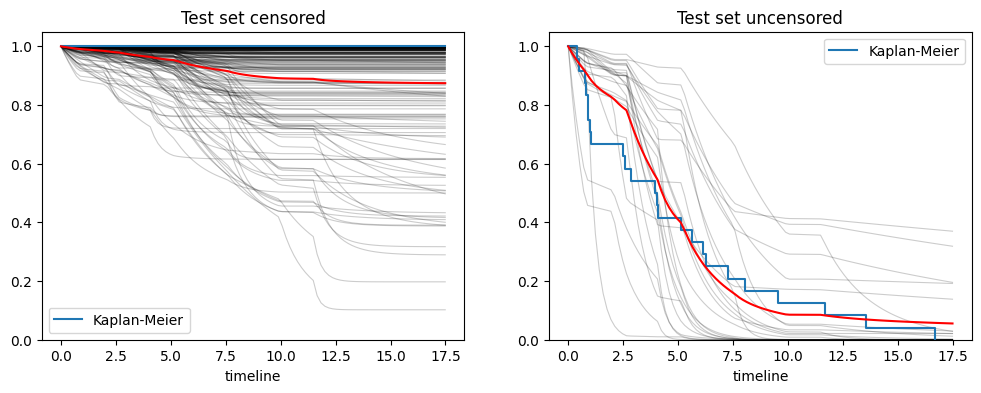

In [29]:
ts_grid = poisson_results["ts_grid"]

p_test = poisson_results["p_test"].numpy()
S_ts_test = poisson_results["S_ts_test"].numpy()
S_ts_test_censored = S_ts_test[delta_test == 0, :]

# Survival curves for the predicted susceptibles (For these patients, we know M > 0, so we condition the cure probability out)
S_ts_test_uncensored = (S_ts_test[delta_test == 1, :] - p_test[delta_test == 1]) / (1-p_test[delta_test == 1])

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier(ts_grid[:,None],
                           S_ts_test_censored.T,
                           y_test[delta_test == 0], delta_test[delta_test == 0], show_individual = True, ax = ax[0])
ax[0].set_title("Test set censored")

utils.average_kaplan_meier(ts_grid[:,None],
                           S_ts_test_uncensored.T,
                           y_test[delta_test == 1], delta_test[delta_test == 1], show_individual = True, ax = ax[1])
ax[1].set_title("Test set uncensored")

plt.show()

## Models alternative to the Poisson

In [30]:
def fit_model(dist, y, delta, x, fixed_q = 0.0, epochs = 5000):
    pwexp_spec = mpscr.BasePiecewiseExp(y = y, delta = delta, n_cuts = 8)

    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 8)
    
    model = mpscr.build_mpscr_model(y, delta, x.shape[1:], model_spec, pwexp_spec,
                                    neural_network = neural_network, neural_network_call = neural_network_call,
                                    neural_network_call_nolast = neural_network_call_nolast,
                                    seed = 10)
    data = [y, delta]
    model.train_model(epochs = epochs, x = x, data = data,
                      shuffle = True,
                      get_covariances = False,
                      validation = True, val_prop = 0.2, force_training_validation = False,
                      optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                      optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                      fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                      early_stopping = True, early_stopping_patience = 50,
                      early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                      reduce_lr = True, reduce_lr_warmup = 0,
                      reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                      reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                      fine_tune = True,
                      finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                      finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                      finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                      finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                      finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                      deterministic = True,
                      verbose = True, print_freq = 1)
    return model

In [ ]:
# with tf.device("/GPU:0"):
#     poisson_model = fit_model("poisson", y_train, delta_train, x_train, fixed_q = 0.0, epochs = 5000)
#     poisson_results = poisson_model.get_survival_cure(y_train, x_train, y_test, x_test, ngrid = 100)

In [31]:
with tf.device("/GPU:0"):
    negbin_model = fit_model("negbin", y_train, delta_train, x_train, epochs = 5000)
    negbin_results = negbin_model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 397 / 5000 ]  | Avg. Train NLL:  0.431892246 | Avg. Validation NLL:  0.561482072 | Best Avg. Validation NLL:  0.55263561 | Speed:  0.165444374  epoch/s    | Elapsed Time:  65.6814194  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 784 / 5000 ]  | Avg. Train NLL:  0.281241626 | Best Avg. Train NLL:  0.281241626 | Avg. Validation NLL:  0.411077529 | Speed:  0.0705236569  epoch/s    | Elapsed Time:  55.2905464  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 127.625 seconds.


In [32]:
with tf.device("/GPU:0"):
    rgp_model = fit_model("rgp", y_train, delta_train, x_train, epochs = 5000)
    rgp_results = rgp_model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 304 / 5000 ]  | Avg. Train NLL:  0.454726696 | Avg. Validation NLL:  0.557889044 | Best Avg. Validation NLL:  0.55182606 | Speed:  0.167551503  epoch/s    | Elapsed Time:  50.9356575  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 827 / 5000 ]  | Avg. Train NLL:  0.27781868 | Best Avg. Train NLL:  0.27781868 | Avg. Validation NLL:  0.469253242 | Speed:  0.0738423467  epoch/s    | Elapsed Time:  61.0676193  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 120.632 seconds.


In [35]:
def plot_susceptibles_survival(model_results, ax1 = None, ax2 = None, show_individual = True):
    if(ax1 is None or ax2 is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
        ax1 = ax[0]
        ax2 = ax[1]
        
    ts_grid = model_results["ts_grid"]

    y_train = model_results["y_train"]
    delta_train = model_results["delta_train"]
    y_test = model_results["y_test"]
    delta_test = model_results["delta_test"]
    
    S_ts_train = model_results["S_ts_train"].numpy()
    S_ts_test = model_results["S_ts_test"].numpy()
    p_train = model_results["p_train"].numpy()
    p_test = model_results["p_test"].numpy()

    # Survival curves for the predicted susceptibles (For these patients, we know M > 0, so we condition the cure probability out)
    S_ts_train_uncensored = (S_ts_train[delta_train == 1, :] - p_train[delta_train == 1]) / (1-p_train[delta_train == 1])
    S_ts_test_uncensored = (S_ts_test[delta_test == 1, :] - p_test[delta_test == 1]) / (1-p_test[delta_test == 1])
    
    utils.average_kaplan_meier(ts_grid[:,None],
                               S_ts_train_uncensored.T,
                               y_train[delta_train == 1], delta_train[delta_train == 1], show_individual = show_individual, ax = ax1)
    ax1.set_title("Train set censored")
    
    utils.average_kaplan_meier(ts_grid[:,None],
                               S_ts_test_uncensored.T,
                               y_test[delta_test == 1], delta_test[delta_test == 1], show_individual = show_individual, ax = ax2)
    ax2.set_title("Test set uncensored")

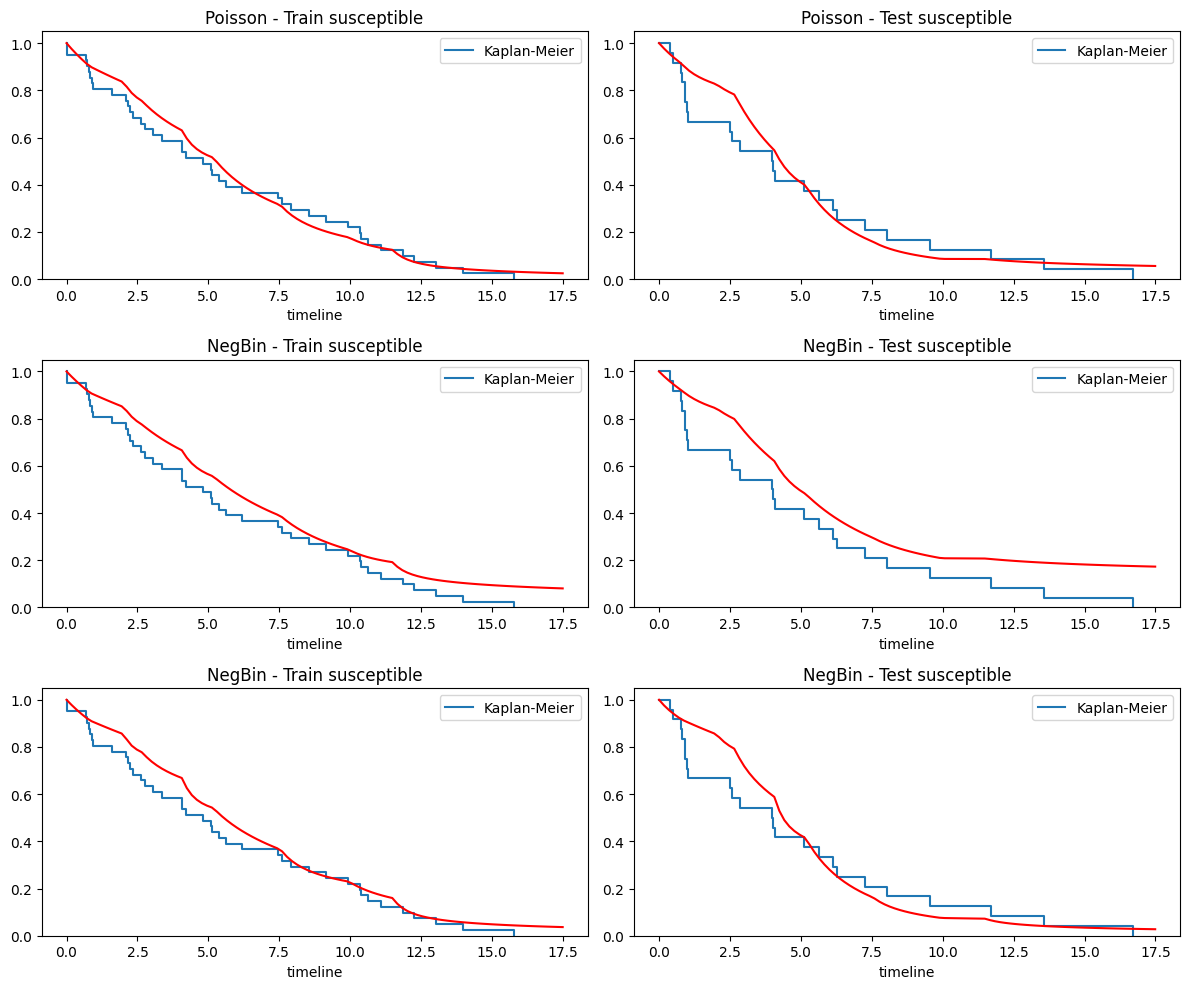

In [36]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,10))

plot_susceptibles_survival(poisson_results, ax1 = ax[0,0], ax2 = ax[0,1], show_individual = False)
ax[0,0].set_title("Poisson - Train susceptible")
ax[0,1].set_title("Poisson - Test susceptible")

plot_susceptibles_survival(negbin_results, ax1 = ax[1,0], ax2 = ax[1,1], show_individual = False)
ax[1,0].set_title("NegBin - Train susceptible")
ax[1,1].set_title("NegBin - Test susceptible")

plot_susceptibles_survival(rgp_results, ax1 = ax[2,0], ax2 = ax[2,1], show_individual = False)
ax[2,0].set_title("NegBin - Train susceptible")
ax[2,1].set_title("NegBin - Test susceptible")

fig.tight_layout()